In [3]:
import os
import cv2
import json
import torch
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [4]:
IMAGE_DIR = "../data/raw/CADB/images"

image_name = "120.jpg"

image_path = os.path.join(
    IMAGE_DIR,
    image_name
)

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

h, w, _ = img_rgb.shape

In [5]:
graph_path = (
    "../data/processed/graphs/"
    + image_name
    + ".json"
)

with open(graph_path, "r") as f:

    graph_data = json.load(f)

G = nx.node_link_graph(graph_data)

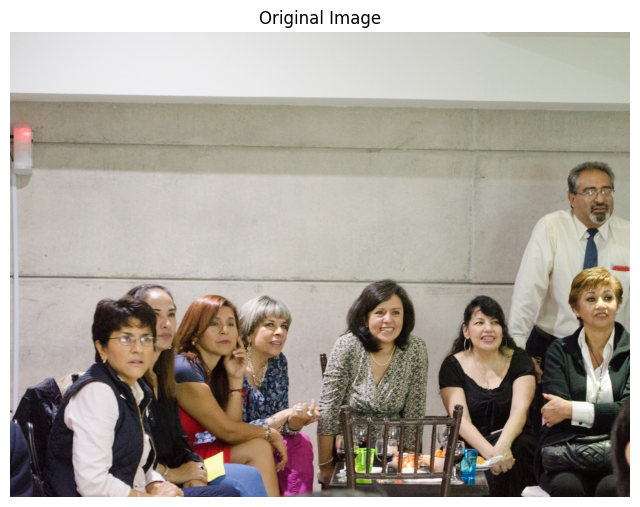

In [6]:
plt.figure(figsize=(8,8))

plt.imshow(img_rgb)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [7]:
thirds_img = img_rgb.copy()

In [8]:
x1 = w // 3
x2 = 2 * w // 3

y1 = h // 3
y2 = 2 * h // 3

In [9]:
cv2.line(thirds_img, (x1,0), (x1,h), (0,255,0), 2)

cv2.line(thirds_img, (x2,0), (x2,h), (0,255,0), 2)

cv2.line(thirds_img, (0,y1), (w,y1), (0,255,0), 2)

cv2.line(thirds_img, (0,y2), (w,y2), (0,255,0), 2)

array([[[216, 216, 214],
        [214, 216, 215],
        [214, 215, 217],
        ...,
        [171, 168, 153],
        [177, 174, 159],
        [173, 170, 153]],

       [[215, 215, 215],
        [213, 215, 214],
        [213, 214, 216],
        ...,
        [172, 169, 154],
        [177, 174, 159],
        [173, 170, 153]],

       [[215, 215, 215],
        [215, 215, 215],
        [214, 215, 217],
        ...,
        [171, 168, 153],
        [174, 171, 156],
        [171, 168, 151]],

       ...,

       [[ 45,  39,  53],
        [ 39,  33,  47],
        [ 34,  28,  42],
        ...,
        [ 46,  35,  31],
        [ 52,  39,  33],
        [ 55,  42,  36]],

       [[ 54,  46,  69],
        [ 48,  40,  63],
        [ 43,  35,  58],
        ...,
        [ 56,  41,  34],
        [ 61,  46,  39],
        [ 61,  47,  38]],

       [[ 59,  53,  81],
        [ 56,  50,  78],
        [ 54,  48,  76],
        ...,
        [ 68,  51,  43],
        [ 72,  55,  45],
        [ 62,  45,  35]]

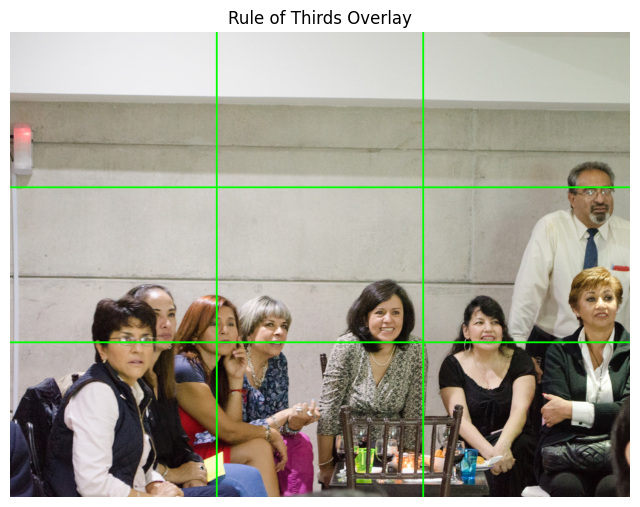

In [10]:
plt.figure(figsize=(8,8))

plt.imshow(thirds_img)

plt.title("Rule of Thirds Overlay")

plt.axis("off")

plt.show()

In [11]:
node_img = img_rgb.copy()

In [12]:
for node, data in G.nodes(data=True):

    cx = int(data["center_x"])

    cy = int(data["center_y"])

    weight = data.get("area", 1000)

    radius = int(
        max(8, min(30, weight / 5000))
    )

    cv2.circle(

        node_img,

        (cx, cy),

        radius,

        (255,0,0),

        -1
    )

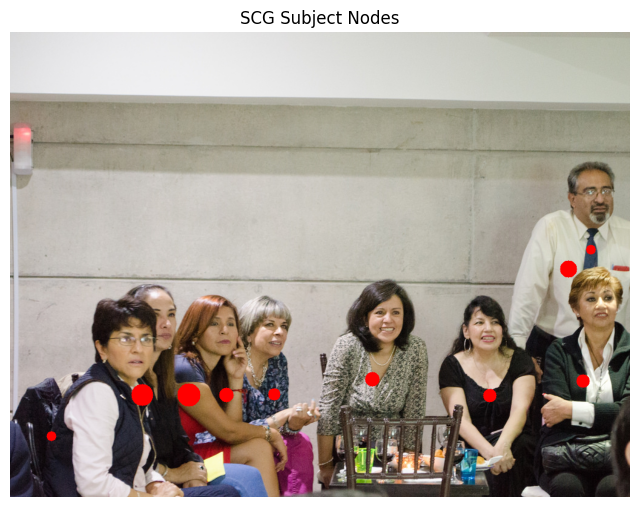

In [13]:
plt.figure(figsize=(8,8))

plt.imshow(node_img)

plt.title("SCG Subject Nodes")

plt.axis("off")

plt.show()

In [14]:
edge_img = node_img.copy()

In [15]:
for u, v, data in G.edges(data=True):

    n1 = G.nodes[u]
    n2 = G.nodes[v]

    x1 = int(n1["center_x"])
    y1 = int(n1["center_y"])

    x2 = int(n2["center_x"])
    y2 = int(n2["center_y"])

    tension = data.get("distance", 100)

    thickness = int(
        max(1, min(8, 500 / (tension + 1)))
    )

    cv2.line(

        edge_img,

        (x1,y1),

        (x2,y2),

        (255,255,0),

        thickness
    )

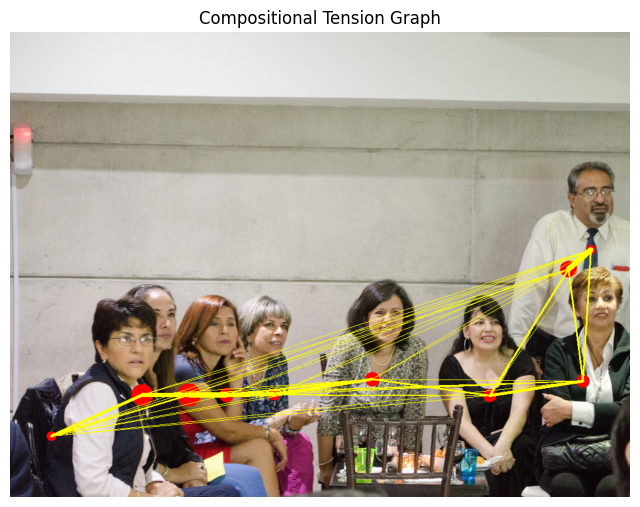

In [16]:
plt.figure(figsize=(8,8))

plt.imshow(edge_img)

plt.title("Compositional Tension Graph")

plt.axis("off")

plt.show()

In [17]:
heatmap = np.zeros((h,w))

In [18]:
for node, data in G.nodes(data=True):

    cx = int(data["center_x"])

    cy = int(data["center_y"])

    area = data.get("area", 1000)

    cv2.circle(

        heatmap,

        (cx,cy),

        80,

        area,

        -1
    )

In [19]:
heatmap = cv2.GaussianBlur(
    heatmap,
    (0,0),
    35
)

heatmap = heatmap / heatmap.max()

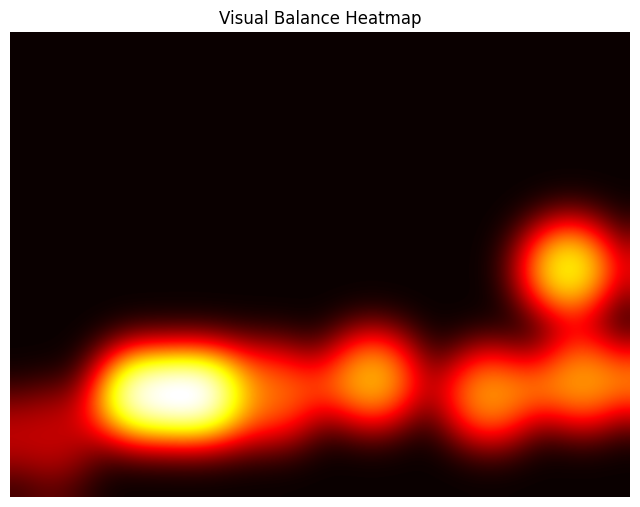

In [20]:
plt.figure(figsize=(8,8))

plt.imshow(
    heatmap,
    cmap="hot"
)

plt.title("Visual Balance Heatmap")

plt.axis("off")

plt.show()

In [21]:
colored_map = plt.cm.hot(heatmap)

In [22]:
colored_map = (
    colored_map[:,:,:3] * 255
).astype(np.uint8)

In [23]:
overlay = cv2.addWeighted(

    img_rgb,

    0.6,

    colored_map,

    0.4,

    0
)

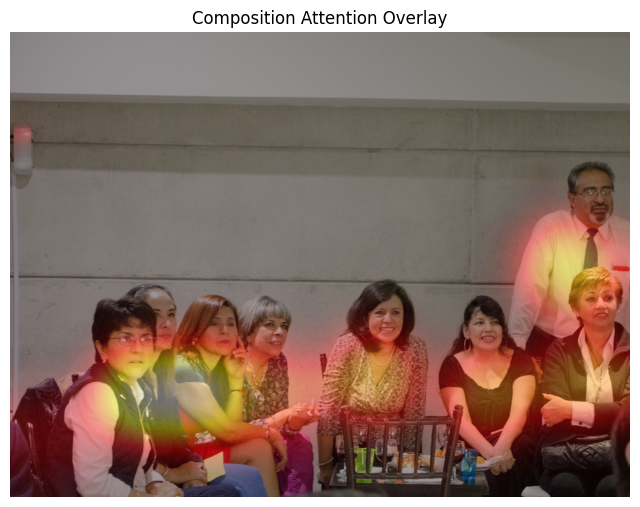

In [24]:
plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title("Composition Attention Overlay")

plt.axis("off")

plt.show()

In [25]:
!pip uninstall opencv-python -y

In [26]:
!pip install opencv-contrib-python


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import cv2
saliency = cv2.saliency.StaticSaliencySpectralResidual_create()

success, saliency_map = saliency.computeSaliency(img)

saliency_map = (
    saliency_map * 255
).astype("uint8")

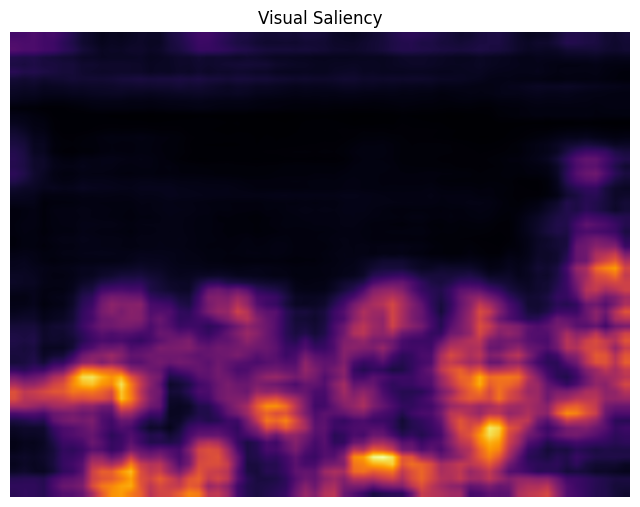

In [28]:
plt.figure(figsize=(8,8))

plt.imshow(
    saliency_map,
    cmap="inferno"
)

plt.title("Visual Saliency")

plt.axis("off")

plt.show()

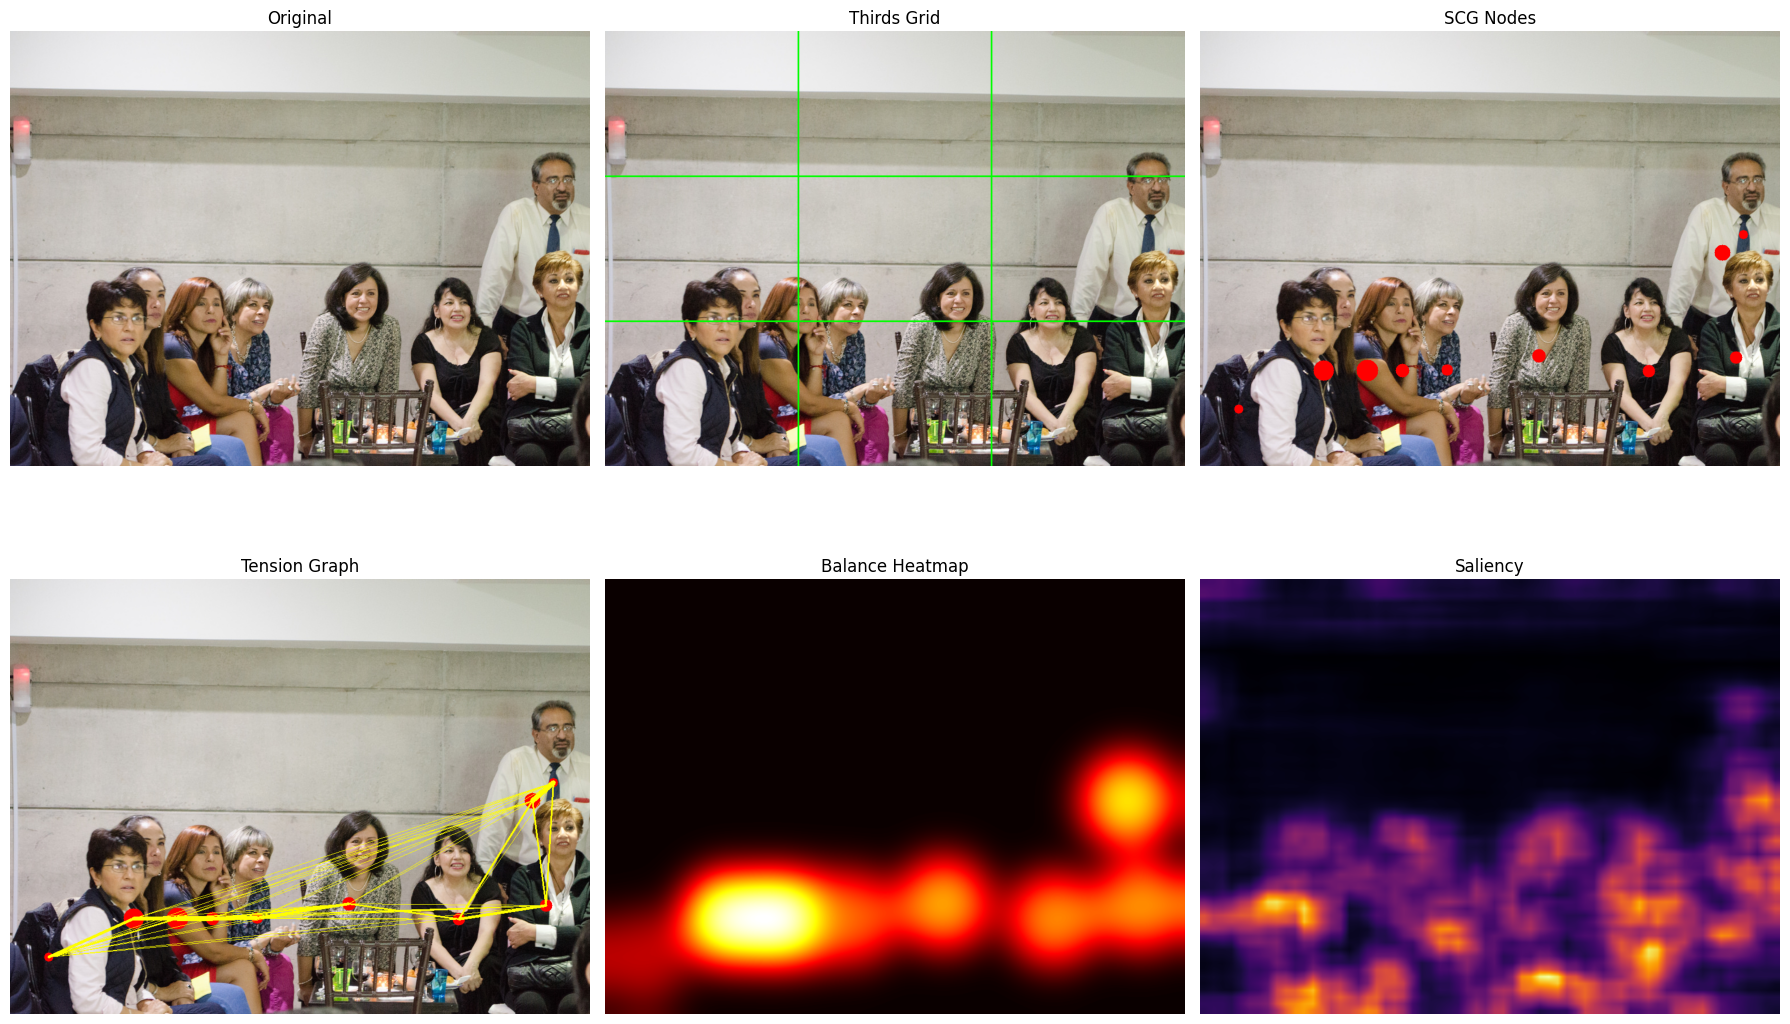

In [33]:
fig, axes = plt.subplots(

    2,
    3,

    figsize=(18,12)
)
axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Original")

axes[0,1].imshow(thirds_img)
axes[0,1].set_title("Thirds Grid")

axes[0,2].imshow(node_img)
axes[0,2].set_title("SCG Nodes")

axes[1,0].imshow(edge_img)
axes[1,0].set_title("Tension Graph")

axes[1,1].imshow(heatmap, cmap="hot")
axes[1,1].set_title("Balance Heatmap")

axes[1,2].imshow(saliency_map, cmap="inferno")
axes[1,2].set_title("Saliency")
for ax in axes.flat:

    ax.axis("off")
plt.tight_layout()

plt.show()